In [1]:
import stpsf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-068 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-071
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf
/home/xingyaocai/miniconda3/envs/DustCurve/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
filter_list = ['F070LP', 'F100LP', 'F170LP', 'F290LP']

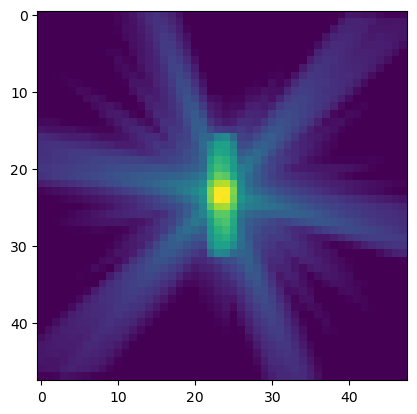

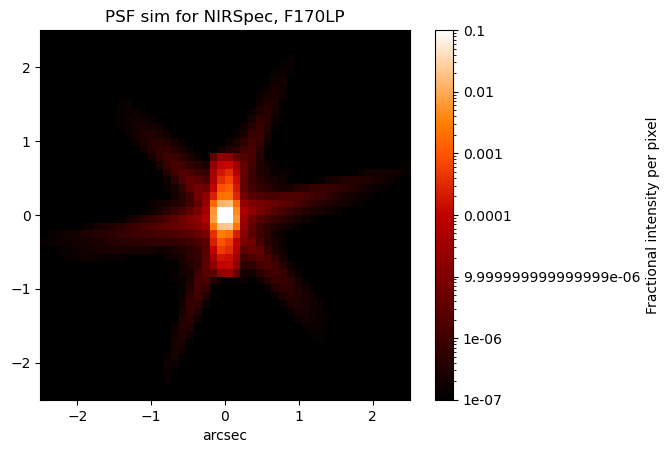

In [23]:
ns = stpsf.NIRSpec()

ns.filter = 'F170LP'
ns.image_mask='Three adjacent MSA open shutters'

msapsf = ns.calc_psf(monochromatic=4.863000000000001e-07, oversample=4)
data=msapsf[3].data
plt.imshow(data, cmap='viridis', norm='log',resample=0.5,vmin=1e-8)
plt.show()
stpsf.display_psf(msapsf, ext=3)

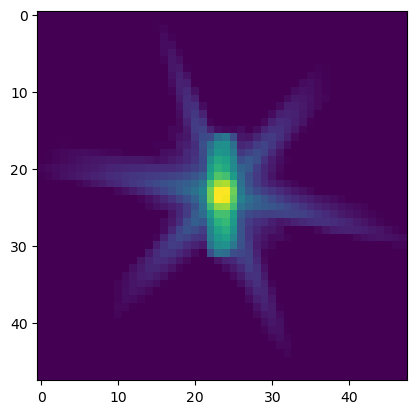

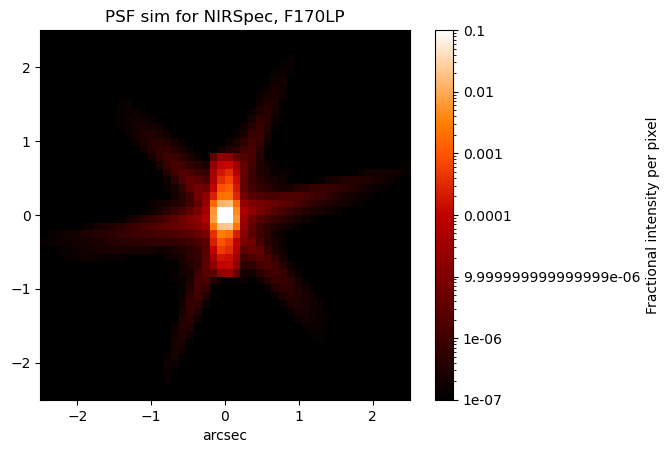

In [28]:
plt.imshow(data, cmap='viridis', norm='log',resample=0.5,vmin=1e-7)
plt.show()
stpsf.display_psf(msapsf, ext=3)

**WARNING**: LOCAL JWST PRD VERSION PRDOPSSOC-068 DOESN'T MATCH THE CURRENT ONLINE VERSION PRDOPSSOC-071
Please consider updating pysiaf, e.g. pip install --upgrade pysiaf or conda update pysiaf
/home/xingyaocai/miniconda3/envs/DustCurve/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


正在初始化 NIRSpec 仪器...
仪器: NIRSpec
滤光片: F170LP

正在计算 4863.0 Angstrom 处的 PSF...
正在计算 6563.0 Angstrom 处的 PSF...

PSF 计算完成。
正在生成图像...


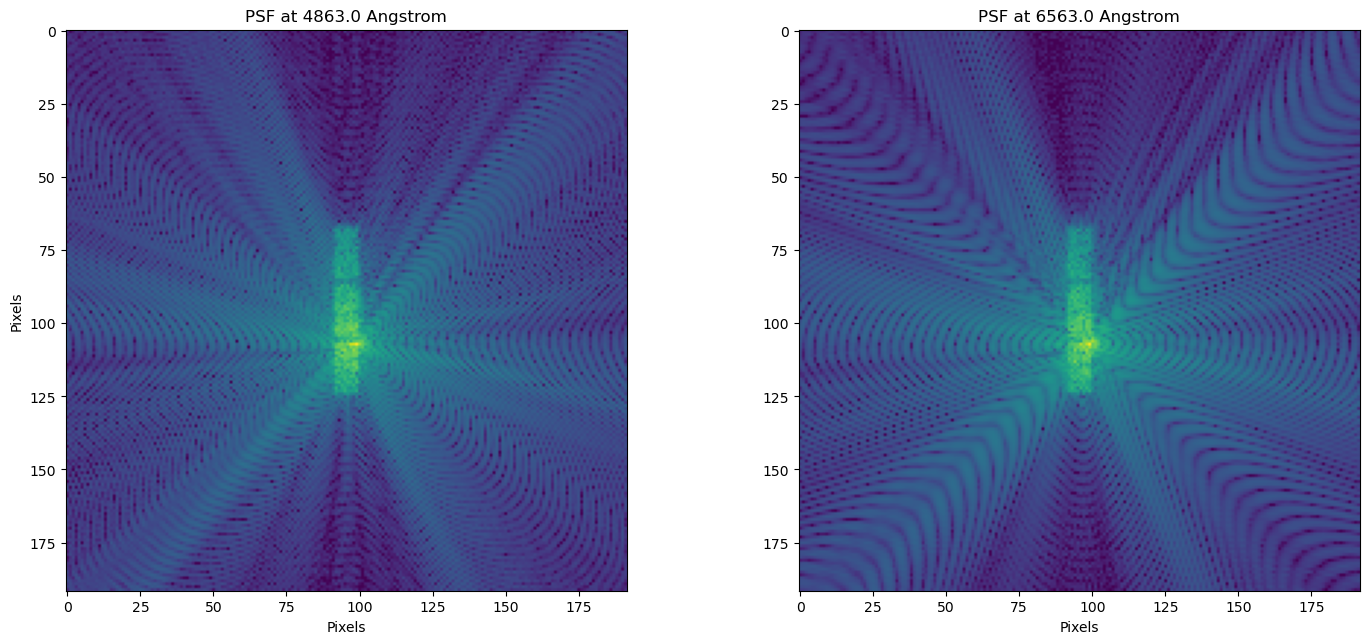

In [1]:
import stpsf
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import astropy.units as u
import numpy as np
import warnings

# 忽略 astropy IERS 数据可能过时的警告
warnings.filterwarnings('ignore', category=UserWarning, message='IERS data is out of date.')

# --- 1. 初始化仪器并进行设置 ---

print("正在初始化 NIRSpec 仪器...")
nirspec = stpsf.NIRSpec()
nirspec.options['source_offset_x']=0.1
nirspec.options['source_offset_y']=0.3
nirspec.filter = 'F170LP'
nirspec.image_mask='Three adjacent MSA open shutters'
#nirspec.apername = 'MSA_3_ADJ' # 使用 apername 是正确的做法

print(f"仪器: {nirspec.name}")
print(f"滤光片: {nirspec.filter}")
#print(f"孔径: {nirspec.apername}")

# --- 2. 定义波长并进行单位转换 ---

wavelength1_A = 4863 * u.AA
wavelength2_A = 6563 * u.AA
wavelength1_m = wavelength1_A.to(u.m).value
wavelength2_m = wavelength2_A.to(u.m).value

# --- 3. 计算两个波长下的 PSF ---

OVERSAMPLE = 4

print(f"\n正在计算 {wavelength1_A} 处的 PSF...")
psf_4863_hdu = nirspec.calc_psf(monochromatic=wavelength1_m, oversample=OVERSAMPLE)
psf_4863_data = psf_4863_hdu[0].data

print(f"正在计算 {wavelength2_A} 处的 PSF...")
psf_6563_hdu = nirspec.calc_psf(monochromatic=wavelength2_m, oversample=OVERSAMPLE)
psf_6563_data = psf_6563_hdu[0].data

print("\nPSF 计算完成。")

# --- 4. 绘制结果 (使用统一的颜色轴) ---

print("正在生成图像...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
#fig.suptitle(f'NIRSpec PSF Simulation with {nirspec.apername} Aperture', fontsize=16)

# *** 新增代码: 确定全局的颜色范围 ***
# 找到两个 PSF 强度的全局最大值
vmax = max(psf_4863_data.max(), psf_6563_data.max())
# 为对数坐标找到一个合适的全局最小值 (避免取到0)
# 我们选择一个比最大值小很多但大于0的数，例如最大值的百万分之一
vmin = vmax / 1e10

# 创建一个可以在两个图之间共享的对数归一化实例
norm = LogNorm(vmin=vmin, vmax=vmax)

# 绘制 4863 Angstrom 的 PSF
# 在 imshow 中传入共享的 norm 参数
im1 = ax1.imshow(psf_4863_data, cmap='viridis', norm=norm)
ax1.set_title(f'PSF at {wavelength1_A}')
ax1.set_xlabel('Pixels')
ax1.set_ylabel('Pixels')


# 绘制 6563 Angstrom 的 PSF
# 在 imshow 中传入完全相同的 norm 参数
im2 = ax2.imshow(psf_6563_data, cmap='viridis', norm=norm)
ax2.set_title(f'PSF at {wavelength2_A}')
ax2.set_xlabel('Pixels')

# 在图像右侧添加一个共享的颜色条
#fig.colorbar(im2, ax=[ax1, ax2], orientation='vertical', label='Intensity (Log Scale)', pad=0.02)


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

正在初始化 NIRSpec 仪器...
仪器: NIRSpec
滤光片: F170LP

正在计算 4863.0 Angstrom 处的 PSF...
正在计算 6563.0 Angstrom 处的 PSF...

PSF 计算完成。
正在生成图像...


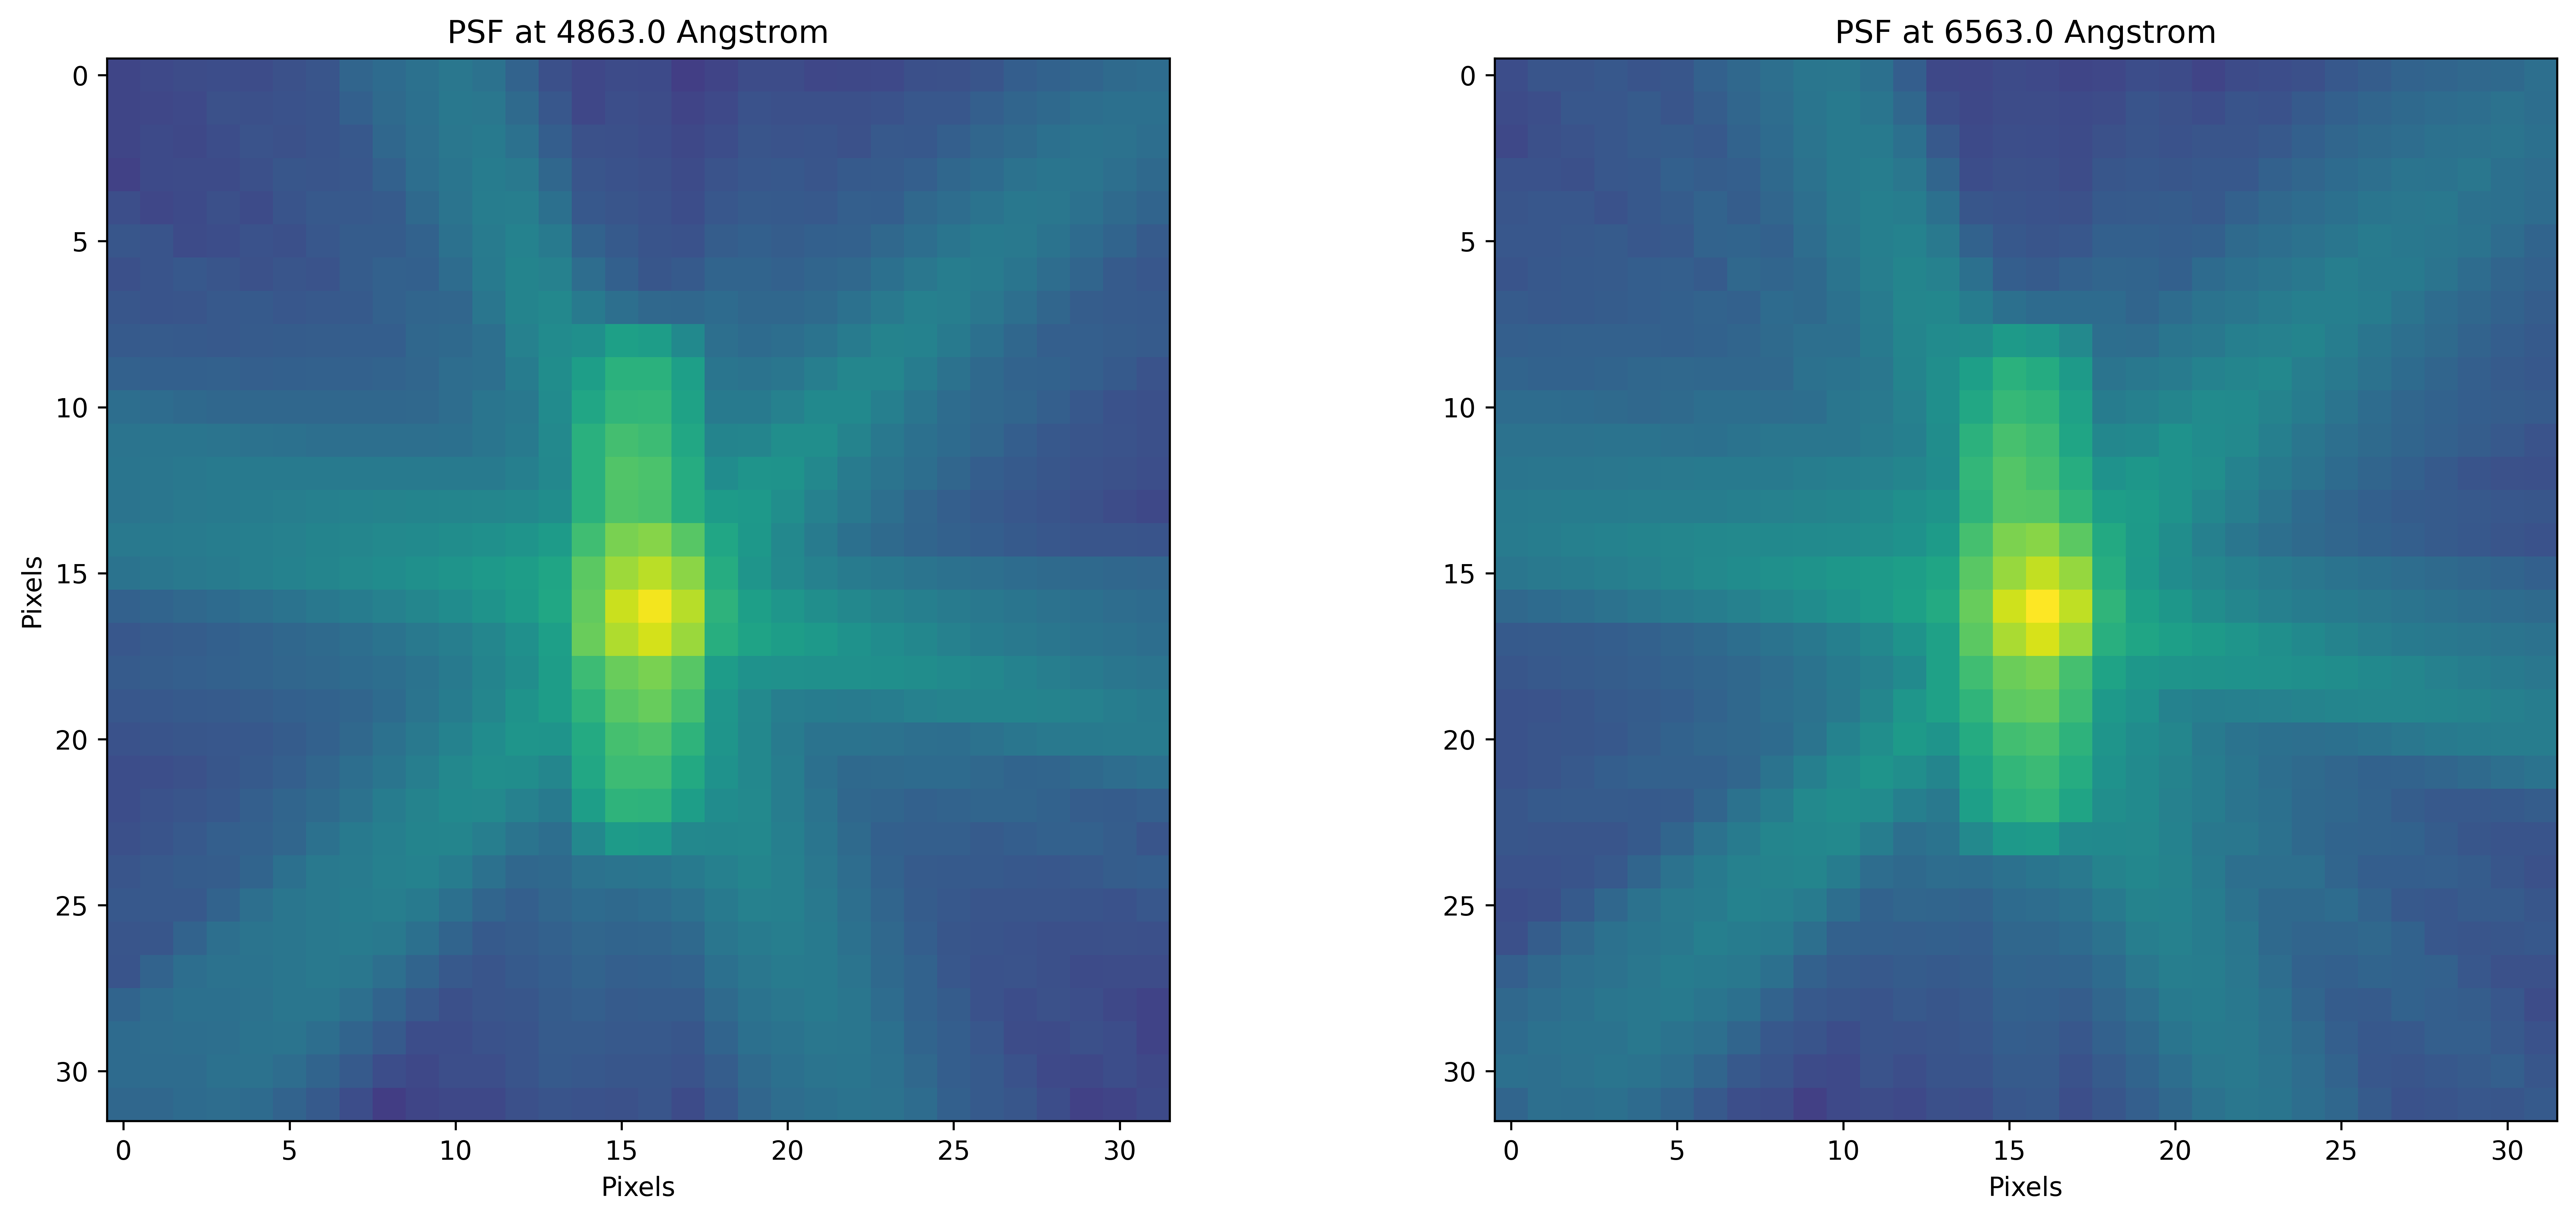

In [19]:
import stpsf
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import astropy.units as u
import numpy as np
import warnings

# 忽略 astropy IERS 数据可能过时的警告
warnings.filterwarnings('ignore', category=UserWarning, message='IERS data is out of date.')

# --- 1. 初始化仪器并进行设置 ---

print("正在初始化 NIRSpec 仪器...")
nirspec = stpsf.NIRSpec()
nirspec.filter = 'F170LP'
nirspec.options['source_offset_x']=0.05
nirspec.options['source_offset_y']=0.07
nirspec.image_mask='Three adjacent MSA open shutters'
#nirspec.apername = 'MSA_3_ADJ' # 使用 apername 是正确的做法

print(f"仪器: {nirspec.name}")
print(f"滤光片: {nirspec.filter}")
#print(f"孔径: {nirspec.apername}")

# --- 2. 定义波长并进行单位转换 ---

wavelength1_A = 4863 * u.AA
wavelength2_A = 6563 * u.AA
wavelength1_m = wavelength1_A.to(u.m).value
wavelength2_m = wavelength2_A.to(u.m).value

# --- 3. 计算两个波长下的 PSF ---

OVERSAMPLE = 4

print(f"\n正在计算 {wavelength1_A} 处的 PSF...")
psf_4863_hdu = nirspec.calc_psf(monochromatic=wavelength1_m, oversample=OVERSAMPLE,fov_pixels=32)
psf_4863_data = psf_4863_hdu[3].data

print(f"正在计算 {wavelength2_A} 处的 PSF...")
psf_6563_hdu = nirspec.calc_psf(monochromatic=wavelength2_m, oversample=OVERSAMPLE,fov_pixels=32)
psf_6563_data = psf_6563_hdu[3].data

print("\nPSF 计算完成。")

# --- 4. 绘制结果 (使用统一的颜色轴) ---

print("正在生成图像...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7), dpi=600)
#fig.suptitle(f'NIRSpec PSF Simulation with {nirspec.apername} Aperture', fontsize=16)

# *** 新增代码: 确定全局的颜色范围 ***
# 找到两个 PSF 强度的全局最大值
vmax = max(psf_4863_data.max(), psf_6563_data.max())
# 为对数坐标找到一个合适的全局最小值 (避免取到0)
# 我们选择一个比最大值小很多但大于0的数，例如最大值的百万分之一
vmin = vmax / 1e10

# 创建一个可以在两个图之间共享的对数归一化实例
norm = LogNorm(vmin=vmin, vmax=vmax)

# 绘制 4863 Angstrom 的 PSF
# 在 imshow 中传入共享的 norm 参数
im1 = ax1.imshow(psf_4863_data, cmap='viridis', norm=norm)
ax1.set_title(f'PSF at {wavelength1_A}')
ax1.set_xlabel('Pixels')
ax1.set_ylabel('Pixels')


# 绘制 6563 Angstrom 的 PSF
# 在 imshow 中传入完全相同的 norm 参数
im2 = ax2.imshow(psf_6563_data, cmap='viridis', norm=norm)
ax2.set_title(f'PSF at {wavelength2_A}')
ax2.set_xlabel('Pixels')

# 在图像右侧添加一个共享的颜色条
#fig.colorbar(im2, ax=[ax1, ax2], orientation='vertical', label='Intensity (Log Scale)', pad=0.02)


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [16]:
psf_6563_hdu.info()

Filename: (No file associated with this HDUList)
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  OVERSAMP      1 PrimaryHDU     116   (640, 640)   float64   
  1  DET_SAMP      1 ImageHDU       118   (160, 160)   float64   
  2  OVERDIST      1 ImageHDU       165   (640, 640)   float64   
  3  DET_DIST      1 ImageHDU       166   (160, 160)   float64   


In [17]:
psf_6563_hdu[0].header

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                  -64 / array data type                                
NAXIS   =                    2 / number of array dimensions                     
NAXIS1  =                  640                                                  
NAXIS2  =                  640                                                  
EXTEND  =                    T                                                  
PLANE1  = 'Wavefront Intensity'                                                 
WAVELEN = 6.56300000000000E-07 / Weighted mean wavelength in meters             
DIFFLMT = 0.020500087884172513 / Diffraction limit lambda/D in arcsec           
OVERSAMP=                    4 / Oversampling factor for FFTs in computation    
DET_SAMP=                    4 / Oversampling factor for MFT to detector plane  
PIXELSCL= 0.026081967499999997 / Scale in arcsec/pix (after oversampling)       
FOV     =           16.69245

In [22]:
psf_6563_hdu[3].data

array([[9.67202423e-09, 1.76997045e-08, 1.75662356e-08, ...,
        9.84379390e-08, 1.12868672e-07, 1.94903894e-07],
       [8.17305504e-09, 1.04287052e-08, 2.17459356e-08, ...,
        1.71278323e-07, 2.43766563e-07, 1.79403717e-07],
       [6.34946791e-09, 1.21076694e-08, 1.47432529e-08, ...,
        2.38942591e-07, 2.87338811e-07, 2.16012414e-07],
       ...,
       [1.36100274e-07, 2.22593219e-07, 2.82163181e-07, ...,
        4.42818027e-08, 2.68007335e-08, 1.43080508e-08],
       [2.11580201e-07, 1.87321766e-07, 2.40221126e-07, ...,
        3.02849909e-08, 4.37427992e-08, 1.92295436e-08],
       [7.88714359e-08, 1.89203479e-07, 1.69631537e-07, ...,
        2.19753047e-08, 1.99274254e-08, 2.91978555e-08]], shape=(32, 32))

正在初始化 NIRSpec 仪器...
仪器: NIRSpec
滤光片: F170LP

正在计算 4863.0 Angstrom 处的 PSF...


/home/xingyaocai/miniconda3/envs/DustCurve/lib/python3.11/site-packages/poppy/instrument.py:691: UserWarning: For wavelength 0.486 microns, a FOV of 16.692 * 16.692 arcsec exceeds the maximum  spatial frequency well sampled by the input pupil. Your computed PSF will suffer from aliasing for angles beyond 7.777 arcsec radius.
  warnings.warn((


正在计算 6563.0 Angstrom 处的 PSF...

PSF 计算完成。
正在生成图像...


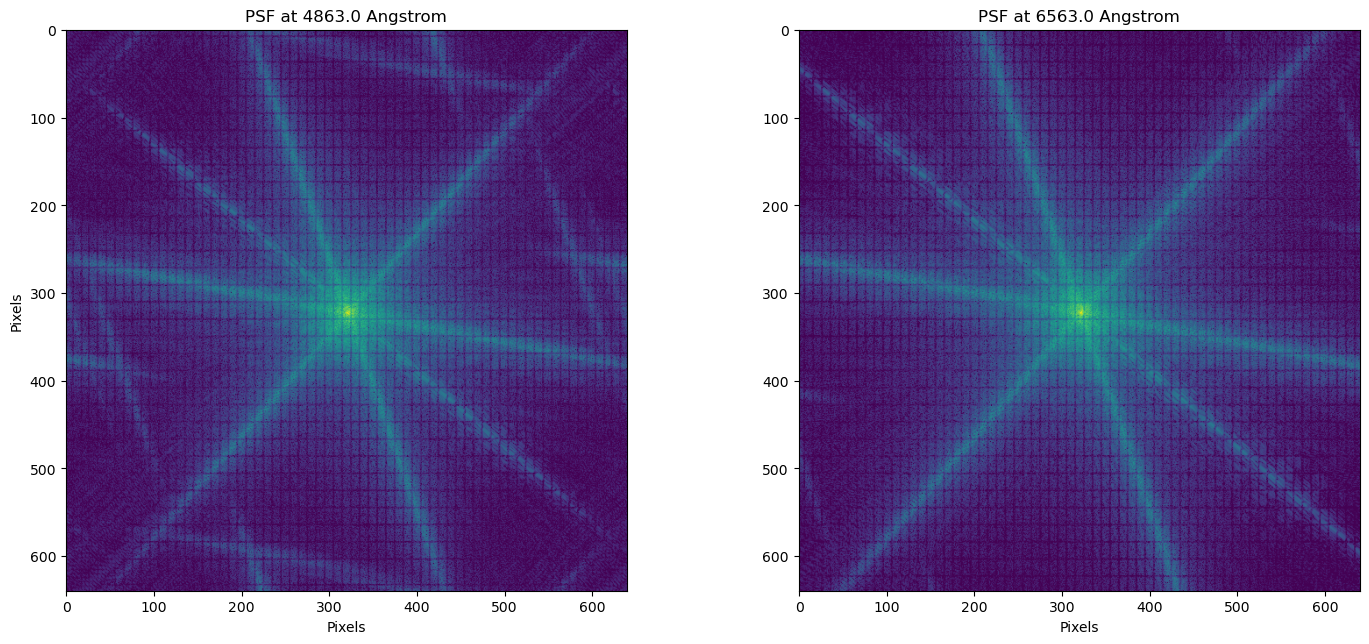

In [18]:
import stpsf
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import astropy.units as u
import numpy as np
import warnings

# 忽略 astropy IERS 数据可能过时的警告
warnings.filterwarnings('ignore', category=UserWarning, message='IERS data is out of date.')

# --- 1. 初始化仪器并进行设置 ---

print("正在初始化 NIRSpec 仪器...")
nirspec = stpsf.NIRSpec()
nirspec.filter = 'F170LP'
nirspec.options['source_offset_x']=0.05
nirspec.options['source_offset_y']=0.07
nirspec.image_mask='MSA all open'
#nirspec.apername = 'MSA_3_ADJ' # 使用 apername 是正确的做法

print(f"仪器: {nirspec.name}")
print(f"滤光片: {nirspec.filter}")
#print(f"孔径: {nirspec.apername}")

# --- 2. 定义波长并进行单位转换 ---

wavelength1_A = 4863 * u.AA
wavelength2_A = 6563 * u.AA
wavelength1_m = wavelength1_A.to(u.m).value
wavelength2_m = wavelength2_A.to(u.m).value

# --- 3. 计算两个波长下的 PSF ---

OVERSAMPLE = 4

print(f"\n正在计算 {wavelength1_A} 处的 PSF...")
psf_4863_hdu = nirspec.calc_psf(monochromatic=wavelength1_m, oversample=OVERSAMPLE, fov_pixels=160)
psf_4863_data = psf_4863_hdu[0].data

print(f"正在计算 {wavelength2_A} 处的 PSF...")
psf_6563_hdu = nirspec.calc_psf(monochromatic=wavelength2_m, oversample=OVERSAMPLE, fov_pixels=160)
psf_6563_data = psf_6563_hdu[0].data

print("\nPSF 计算完成。")

# --- 4. 绘制结果 (使用统一的颜色轴) ---

print("正在生成图像...")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))
#fig.suptitle(f'NIRSpec PSF Simulation with {nirspec.apername} Aperture', fontsize=16)

# *** 新增代码: 确定全局的颜色范围 ***
# 找到两个 PSF 强度的全局最大值
vmax = max(psf_4863_data.max(), psf_6563_data.max())
# 为对数坐标找到一个合适的全局最小值 (避免取到0)
# 我们选择一个比最大值小很多但大于0的数，例如最大值的百万分之一
vmin = vmax / 1e10

# 创建一个可以在两个图之间共享的对数归一化实例
norm = LogNorm(vmin=vmin, vmax=vmax)

# 绘制 4863 Angstrom 的 PSF
# 在 imshow 中传入共享的 norm 参数
im1 = ax1.imshow(psf_4863_data, cmap='viridis', norm=norm)
ax1.set_title(f'PSF at {wavelength1_A}')
ax1.set_xlabel('Pixels')
ax1.set_ylabel('Pixels')


# 绘制 6563 Angstrom 的 PSF
# 在 imshow 中传入完全相同的 norm 参数
im2 = ax2.imshow(psf_6563_data, cmap='viridis', norm=norm)
ax2.set_title(f'PSF at {wavelength2_A}')
ax2.set_xlabel('Pixels')

# 在图像右侧添加一个共享的颜色条
#fig.colorbar(im2, ax=[ax1, ax2], orientation='vertical', label='Intensity (Log Scale)', pad=0.02)


plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

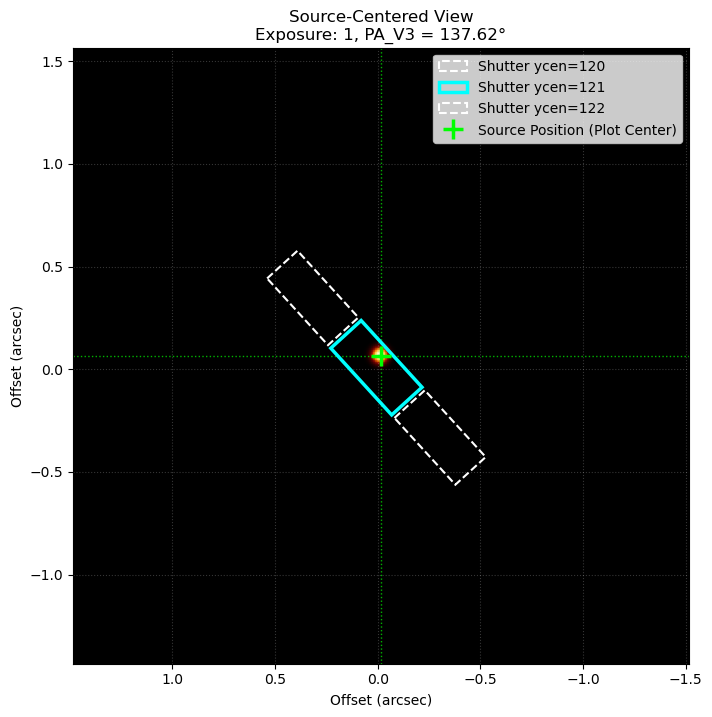

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# --- 1. 定义 NIRSpec MSA 快门常量 ---
SHUTTER_WIDTH_ARCSEC = 0.20  # 色散方向
SHUTTER_HEIGHT_ARCSEC = 0.46 # 交叉色散方向

# --- 2. 您的观测数据 ---
obs_data = [
    ('jw04446001001_03101_00001_nrs1_f100lp_g140m_raw.42.4446_511.fits', 1692, 34, 9.83316762, -10.10036492, 15.39073173, 0.1034026, 0.16797236, 511, '4446_511', 171.8278747, 42.48567156, 0.05599999, -0.03799999, '1x1', 44081, 42, -2.2, 2.2, 4, 281, 121, 357, 1692, 211, 34, 'NRS1', 'G140M', 'F100LP', 'jw04446001001_01_msa.fits', 1, 1, 1458.889, 5, 20, 1, 'NRSIRS2', 60056.77958195, 42.4474189, 137.61726042, 172.00791935, '3-SHUTTER-SLITLET', 1, 'NONE', 3, -38.60351664, -2.59930635),
    ('jw04446001001_03101_00002_nrs1_f100lp_g140m_raw.42.4446_511.fits', 1692, 34, 9.83316762, -10.10036492, 20.50640663, 0.1034026, 0.16797236, 511, '4446_511', 171.8278747, 42.48567156, 0.04699999, -0.05000001, 'x11', 43716, 42, -1.05, 3.35, 4, 281, 120, 357, 1692, 211, 34, 'NRS1', 'G140M', 'F100LP', 'jw04446001001_01_msa.fits', 1, 1, 1458.889, 5, 20, 1, 'NRSIRS2', 60056.79781822, 42.44740331, 137.61730611, 172.00811756, '3-SHUTTER-SLITLET', 2, 'NONE', 3, -38.60350931, -2.07033228),
    ('jw04446001001_03101_00003_nrs1_f100lp_g140m_raw.42.4446_511.fits', 1692, 34, 9.83316762, -10.10036492, 10.2746088, 0.1034026, 0.16797236, 511, '4446_511', 171.8278747, 42.48567156, 0.06599998, -0.02599999, '11x', 44446, 42, -3.35, 1.05, 4, 281, 122, 357, 1692, 211, 34, 'NRS1', 'G140M', 'F100LP', 'jw04446001001_01_msa.fits', 1, 1, 1458.889, 5, 20, 1, 'NRSIRS2', 60056.8158856, 42.44743482, 137.61709658, 172.00772145, '3-SHUTTER-SLITLET', 3, 'NONE', 3, -38.60352677, -3.12832674)
]

# --- 3. 选择要绘制的曝光 ---
exposure_to_plot = 0
selected_data = obs_data[exposure_to_plot]

# 提取相关信息
source_xpos = selected_data[12]
source_ypos = selected_data[13]
active_shutter_ycen = selected_data[21]
pa_v3 = selected_data[39]

# --- 4. 关键步骤：首先计算源的最终位置 ---
# 这将成为我们绘图的中心
angle_rad = np.deg2rad(pa_v3)
cos_a, sin_a = np.cos(angle_rad), np.sin(angle_rad)

# 计算活动快门在slitlet-center坐标系中的中心位置
active_shutter_local_y_center = (active_shutter_ycen - 121) * SHUTTER_HEIGHT_ARCSEC
active_shutter_local_center = np.array([0, active_shutter_local_y_center])

# 旋转活动快门的中心
rotated_shutter_center_x = active_shutter_local_center[0] * cos_a - active_shutter_local_center[1] * sin_a
rotated_shutter_center_y = active_shutter_local_center[0] * sin_a + active_shutter_local_center[1] * cos_a

# 将源的偏移量添加到旋转后的快门中心，得到源的最终绝对坐标
final_source_x = rotated_shutter_center_x + (source_xpos * cos_a - source_ypos * sin_a)
final_source_y = rotated_shutter_center_y + (source_xpos * sin_a + source_ypos * cos_a)

# --- 5. 设置绘图 ---
fig, ax = plt.subplots(figsize=(8, 8))

# --- 6. 绘制以源为中心的PSF ---
# 定义PSF图像在屏幕上显示的角秒尺寸
psf_display_width = 3.0  # arcsec
psf_half_width = psf_display_width / 2.0

# 创建一个高斯函数作为PSF的模拟
x, y = np.mgrid[-psf_half_width:psf_half_width:.01, -psf_half_width:psf_half_width:.01]
pos = np.dstack((x, y))
# FWHM ~ 0.06" for JWST, so sigma ~ 0.025
rv = np.exp(-((pos[:, :, 0]**2 + pos[:, :, 1]**2) / (2.0 * 0.025**2)))

# 使用 extent 参数将 PSF 图像精确地放置在以 final_source 为中心的位置
ax.imshow(rv,
          extent=[final_source_x - psf_half_width, final_source_x + psf_half_width,
                  final_source_y - psf_half_width, final_source_y + psf_half_width],
          origin='lower',
          cmap='afmhot', # 使用更像PSF的颜色映射
          zorder=0) # 确保PSF在最底层

# --- 7. 绘制 Slitlet ---
# 这部分代码与之前相同，因为它在绝对坐标系中绘制slitlet，现在该坐标系的中心就是源
transform = plt.matplotlib.transforms.Affine2D().rotate_deg(pa_v3) + ax.transData
shutter_ycens = [120, 121, 122]
for ycen in shutter_ycens:
    local_y_center = (ycen - 121) * SHUTTER_HEIGHT_ARCSEC
    local_bottom_left_x = -SHUTTER_WIDTH_ARCSEC / 2
    local_bottom_left_y = local_y_center - SHUTTER_HEIGHT_ARCSEC / 2

    is_active = (ycen == active_shutter_ycen)
    edge_color = 'cyan' if is_active else 'white'
    line_style = '-' if is_active else '--'
    line_width = 2.5 if is_active else 1.5

    rect = patches.Rectangle(
        (local_bottom_left_x, local_bottom_left_y),
        SHUTTER_WIDTH_ARCSEC,
        SHUTTER_HEIGHT_ARCSEC-0.02,
        linewidth=line_width,
        linestyle=line_style,
        edgecolor=edge_color,
        facecolor='none',
        transform=transform,
        label=f'Shutter ycen={ycen}',
        zorder=5 # 确保slitlet在PSF之上
    )
    ax.add_patch(rect)

# --- 8. 标记源的位置并添加中心十字线 ---
# 十字线可以明确地显示图像中心
ax.axhline(final_source_y, color='lime', linestyle=':', linewidth=1, alpha=0.7)
ax.axvline(final_source_x, color='lime', linestyle=':', linewidth=1, alpha=0.7)

# 在中心点放置一个标记
ax.plot(
    final_source_x,
    final_source_y,
    '+',
    color='lime',
    markersize=15,
    mew=2.5,
    label='Source Position (Plot Center)',
    zorder=10 # 确保标记在最顶层
)

# --- 9. 完成绘图 ---
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('Offset (arcsec)')
ax.set_ylabel('Offset (arcsec)')
ax.set_title(f"Source-Centered View\nExposure: {exposure_to_plot + 1}, PA_V3 = {pa_v3:.2f}°")
ax.grid(True, linestyle=':', alpha=0.3)

# 创建一个自定义图例
handles, labels = ax.get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
ax.legend(unique_labels.values(), unique_labels.keys(), loc='upper right')

# 设置绘图范围，使其围绕源为中心
plot_view_radius = 1.5 # arcsec
ax.set_xlim(final_source_x - plot_view_radius, final_source_x + plot_view_radius)
ax.set_ylim(final_source_y - plot_view_radius, final_source_y + plot_view_radius)

# 反转x轴以匹配天空坐标系中东方在左的惯例
ax.invert_xaxis()

plt.show()

In [2]:
import bagpipes as pipes